In [2]:
import sys
import os
import pandas as pd
from scipy.stats import spearmanr,linregress
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Calculate the Spearman Correlation coefficients

Adapted from proteingym/performance_DMS_benchmarks.py

Modified from https://github.com/OATML-Markslab/ProteinGym/blob/main/config.json

In [1]:
model_score_dir = '/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/model_scores/zero_shot_substitutions'

model_dict = {
    "model_list_zero_shot_substitutions_DMS": {
        "Site_Independent":{"input_score_name":"prediction_independent", "location":"EVmutation", "directionality": 1, "key": "mutant", "model_type":"MSA"},
        "EVmutation":{"input_score_name":"prediction_epistatic", "location":"EVmutation", "directionality": 1, "key": "mutant", "model_type":"MSA"},
        "EVE_ensemble":{"input_score_name":"evol_indices_ensemble", "location":"EVE_threshold_focus_cols_frac_gaps", "directionality": -1, "key": "mutant","model_type":"MSA"},
        "MSA_Transformer_ensemble":{"input_score_name":"esm_msa1b_t12_100M_UR50S_ensemble", "location":"MSA_Transformer", "directionality": 1, "key": "mutant","model_type":"MSA"},
        "ESM2_650M":{"input_score_name":"esm2_t33_650M_UR50D", "location":"ESM2_650M", "directionality": 1, "key": "mutant","model_type":"Single sequence"},
        "GEMME":{"input_score_name":"GEMME_score", "location":"GEMME", "directionality": 1, "key": "mutant","model_type":"MSA"},
        "VespaG":{"input_score_name":"VespaG", "location":"VespaG", "directionality": 1, "key": "mutant","model_type":"Single sequence"},
        "Tranception_L_no_retrieval":{"input_score_name":"avg_score", "location":"Tranception_L_no_retrieval", "directionality": 1, "key": "mutated_sequence","model_type":"Single sequence"},
        "Tranception_L":{"input_score_name":"avg_score", "location":"Tranception_L_retrieval", "directionality": 1, "key": "mutated_sequence","model_type":"MSA"},
        "TranceptEVE_L":{"input_score_name":"avg_score", "location":"TranceptEVE_L", "directionality": 1, "key": "mutant","model_type":"MSA"},
        "ESM-IF1_142M": {"input_score_name": "esmif1_ll","location":"ESM-IF1-142M","directionality":1,"key":"mutant","model_type":"Structure"},
        "ProteinMPNN": {"input_score_name": "pmpnn_ll","location":"ProteinMPNN","directionality":1,"key":"mutant","model_type":"Structure"},
        "SaProt_650M_AF2":{"input_score_name":"SaProt_score", "location":"SaProt_650M_AF2", "directionality": 1, "key": "mutant", "model_type":"Single sequence & Structure"},
        "PoET": {"input_score_name": "PoET_score","location":"PoET","directionality":1,"key":"mutated_sequence","model_type":"MSA"},
        "ESCOTT":{"input_score_name":"ESCOTT_score", "location":"ESCOTT", "directionality": 1, "key": "mutant","model_type":"Structure & MSA"},
        "VenusREM":{"input_score_name":"VenusREM", "location":"VenusREM", "directionality": 1, "key": "mutant","model_type":"Structure & MSA"},
        "ProSST-2048":{"input_score_name":"ProSST-2048", "location":"ProSST-2048", "directionality": 1, "key": "mutant","model_type":"Single sequence & Structure"},
        "RSALOR":{"input_score_name":"RSALOR", "location":"RSALOR", "directionality": -1, "key": "mutant","model_type":"Structure & MSA"},
        # "S3F":{"input_score_name":"s3f_score", "location":"S3F", "directionality": 1, "key": "mutant","model_type":"Single sequence & Structure"},
        # "S3F_MSA":{"input_score_name":"s3f_MSA_score", "location":"S3F", "directionality": 1, "key": "mutant","model_type":"Structure & MSA"},
        "ESM3_1.4B_open":{"input_score_name":"ESM3_open_score", "location":"ESM3", "directionality": 1, "key": "mutant", "model_type":"Single sequence, Structure & Function annotations"},
        "Progen3_3B":{"input_score_name":"log_likelihood", "location":"ProGen3", "directionality": 1, "key": "mutant","model_type":"Single sequence"},
        "AIDO.Protein-RAG-16B":{"input_score_name":"AIDO.Protein-RAG-16B-zeroshot", "location":"AIDO", "directionality": 1, "key": "mutant","model_type":"Structure & MSA"},
    }
}

In [3]:
reference_file = pd.read_csv('/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/EVCouplings/output/Beltran_Lehner_2025/temp_ref_file.csv')
DMS_folder = "/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned"
list_DMS = reference_file['DMS_id']
model_list = model_dict["model_list_zero_shot_substitutions_DMS"].keys()

In [4]:
DMS_spearman = {'DMS_ID': [], 'number of mutants': []}

for model in model_list:
    if model not in DMS_spearman:
        DMS_spearman[model] = np.full(shape=len(list_DMS), fill_value=np.nan)
    else:
        print(f"Duplicate model name {model}")
    
for i, DMS_id in enumerate(list_DMS):
    print(DMS_id)
    DMS_spearman['DMS_ID'].append(DMS_id)

    DMS_file = DMS_folder + os.sep + reference_file.iloc[i]["DMS_filename"]
    print(DMS_file)
    
    try:
        DMS_score = pd.read_csv(DMS_file)
        DMS_spearman['number of mutants'].append(len(DMS_score))
    except:
        print(f"No DMS scores for {DMS_id}")
        DMS_spearman['number of mutants'].append(0)
        continue
    
    for model in model_list:
        try:
            model_score = pd.read_csv(model_score_dir + os.sep + model_dict["model_list_zero_shot_substitutions_DMS"][model]["location"] + os.sep + DMS_id + ".csv")
        except:
            print(f"Scoring file for {DMS_id} in {model} missing")
            DMS_spearman[model][i] = -1 # this line can be taken out later
            continue
        
        if 'DMS_score' in model_score.columns:
            DMS_spearman[model][i] = spearmanr(model_score['DMS_score'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"]).statistic
        elif model == "Site_Independent" or model == "EVmutation":
            DMS_spearman[model][i] = spearmanr(model_score['normalized_fitness'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"]).statistic            
        else:
            if model == "EVE_ensemble":
                model_score['evol_indices_ensemble'] = model_score.drop('mutant', axis=1).mean(axis=1)
            merged_df = pd.merge(model_score, DMS_score, on=model_dict["model_list_zero_shot_substitutions_DMS"][model]['key'], how='inner')
            DMS_spearman[model][i] = spearmanr(merged_df['DMS_score'], merged_df[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"]).statistic

A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2.csv
FEZF1_HUMAN_Beltran_2025_PF00096_289
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FEZF1_HUMAN_Beltran_2025_PF00096_289.csv
SPD2B_HUMAN_Beltran_2025_PF00018_155
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SPD2B_HUMAN_Beltran_2025_PF00018_155.csv
SPD2B_HUMAN_Beltran_2025_PF00018_222
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SPD2B_HUMAN_Beltran_2025_PF00018_222.csv
A2RRE5_HUMAN_Beltran_2025_PF01846_267
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/A2RRE5_HUMAN_Beltran_2025_PF01846_267.csv
ASB14_HUMAN_Beltran_2025_PF07525_532
/n/groups/

/tmp/ipykernel_351247/2304906901.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  DMS_spearman[model][i] = spearmanr(model_score['DMS_score'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"]).statistic
/tmp/ipykernel_351247/2304906901.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  DMS_spearman[model][i] = spearmanr(model_score['DMS_score'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"]).statistic


ZIC3_HUMAN_Beltran_2025_PF00096_389
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ZIC3_HUMAN_Beltran_2025_PF00096_389.csv
BRD4_HUMAN_Beltran_2025_PF17035_607
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/BRD4_HUMAN_Beltran_2025_PF17035_607.csv
LDB3_HUMAN_Beltran_2025_PF00595_1
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/LDB3_HUMAN_Beltran_2025_PF00595_1.csv
PROP1_HUMAN_Beltran_2025_PF00046_71
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/PROP1_HUMAN_Beltran_2025_PF00046_71.csv
AVIL_HUMAN_Beltran_2025_PF02209_785
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/AVIL_HUMAN_Beltran_2025_PF02209_785.csv
FLNB_HUMAN_Beltran_2025_PF00630_1423
/n/groups/marks/projects/marks_l

ABL1_HUMAN_Beltran_2025_PF00018_64
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ABL1_HUMAN_Beltran_2025_PF00018_64.csv
ICI2_HORVU_Beltran_2025_PF00280_22
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ICI2_HORVU_Beltran_2025_PF00280_22.csv
RL9_GEOSE_Beltran_2025_PF01281_1
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/RL9_GEOSE_Beltran_2025_PF01281_1.csv
SPTA1_HUMAN_Beltran_2025_PF00018_979
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SPTA1_HUMAN_Beltran_2025_PF00018_979.csv
TNNC2_HUMAN_Beltran_2025_PF13499_1
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/TNNC2_HUMAN_Beltran_2025_PF13499_1.csv
S100G_BOVIN_Beltran_2025_PF01023_1
/n/groups/marks/projects/marks_lab_and_o

HXB1_HUMAN_Beltran_2025_PF00046_208
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/HXB1_HUMAN_Beltran_2025_PF00046_208.csv
PO2F1_HUMAN_Beltran_2025_PF00157_285
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/PO2F1_HUMAN_Beltran_2025_PF00157_285.csv
ETS1_HUMAN_Beltran_2025_PF02198_55
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ETS1_HUMAN_Beltran_2025_PF02198_55.csv
BRAF_HUMAN_Beltran_2025_PF02196_153
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/BRAF_HUMAN_Beltran_2025_PF02196_153.csv
VAV_HUMAN_Beltran_2025_PF00018_592
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/VAV_HUMAN_Beltran_2025_PF00018_592.csv
VAV_HUMAN_Beltran_2025_PF00018_782
/n/groups/marks/projects/marks_l

...

AHI1_HUMAN_Beltran_2025_PF00018_1053
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/AHI1_HUMAN_Beltran_2025_PF00018_1053.csv
CRBG2_HUMAN_Beltran_2025_PF00030_1358
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/CRBG2_HUMAN_Beltran_2025_PF00030_1358.csv
ARG28_HUMAN_Beltran_2025_PF00130_651
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ARG28_HUMAN_Beltran_2025_PF00130_651.csv
FNBP4_HUMAN_Beltran_2025_PF00397_200
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FNBP4_HUMAN_Beltran_2025_PF00397_200.csv
FNBP4_HUMAN_Beltran_2025_PF00397_593
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FNBP4_HUMAN_Beltran_2025_PF00397_593.csv
TAB3_HUMAN_Beltran_2025_PF02845_12
/n/groups/marks/pr

LCOR_HUMAN_Beltran_2025_PF05225_353
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/LCOR_HUMAN_Beltran_2025_PF05225_353.csv
MAEL_HUMAN_Beltran_2025_PF09011_3
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/MAEL_HUMAN_Beltran_2025_PF09011_3.csv
PDLI2_HUMAN_Beltran_2025_PF00412_284
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/PDLI2_HUMAN_Beltran_2025_PF00412_284.csv
ZC3HA_HUMAN_Beltran_2025_PF00642_138
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ZC3HA_HUMAN_Beltran_2025_PF00642_138.csv
DNJC1_HUMAN_Beltran_2025_PF00249_494
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/DNJC1_HUMAN_Beltran_2025_PF00249_494.csv
KI16B_HUMAN_Beltran_2025_PF00787_1213
/n/groups/marks/projects/

/tmp/ipykernel_351247/2304906901.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  DMS_spearman[model][i] = spearmanr(model_score['DMS_score'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"]).statistic
/tmp/ipykernel_351247/2304906901.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  DMS_spearman[model][i] = spearmanr(model_score['DMS_score'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"]).statistic
/tmp/ipykernel_351247/2304906901.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  DMS_spearman[model][i] = spearmanr(model_score['DMS_score'], model_score[model_dict["model_list_zero_shot_

ALX4_HUMAN_Beltran_2025_PF00046_216
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ALX4_HUMAN_Beltran_2025_PF00046_216.csv
ADNP_HUMAN_Beltran_2025_PF00046_770
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ADNP_HUMAN_Beltran_2025_PF00046_770.csv
UBQL3_HUMAN_Beltran_2025_PF00627_613
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/UBQL3_HUMAN_Beltran_2025_PF00627_613.csv
P63_HUMAN_Beltran_2025_PF07647_545
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/P63_HUMAN_Beltran_2025_PF07647_545.csv
DNJC5_HUMAN_Beltran_2025_PF00226_16
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/DNJC5_HUMAN_Beltran_2025_PF00226_16.csv
WNK1_HUMAN_Beltran_2025_PF12202_481
/n/groups/marks/projects/mark

BAZ2B_HUMAN_Beltran_2025_PF00628_1927
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/BAZ2B_HUMAN_Beltran_2025_PF00628_1927.csv
ZMYM5_HUMAN_Beltran_2025_PF06467_334
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ZMYM5_HUMAN_Beltran_2025_PF06467_334.csv
SALL4_HUMAN_Beltran_2025_PF00096_383
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SALL4_HUMAN_Beltran_2025_PF00096_383.csv
SALL4_HUMAN_Beltran_2025_PF00096_627
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SALL4_HUMAN_Beltran_2025_PF00096_627.csv
SALL4_HUMAN_Beltran_2025_PF00096_899
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SALL4_HUMAN_Beltran_2025_PF00096_899.csv
TRIM1_HUMAN_Beltran_2025_PF00643_191
/n/groups/marks/

In [5]:
DMS_spearman

{'DMS_ID': ['A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2',
  'FEZF1_HUMAN_Beltran_2025_PF00096_289',
  'SPD2B_HUMAN_Beltran_2025_PF00018_155',
  'SPD2B_HUMAN_Beltran_2025_PF00018_222',
  'A2RRE5_HUMAN_Beltran_2025_PF01846_267',
  'ASB14_HUMAN_Beltran_2025_PF07525_532',
  'WWP2_HUMAN_Beltran_2025_PF00397_440',
  'ODPX_HUMAN_Beltran_2025_PF02817_181',
  'CUX2_HUMAN_Beltran_2025_PF02376_1036',
  'CUX2_HUMAN_Beltran_2025_PF02376_895',
  'DVL1_HUMAN_Beltran_2025_PF00595_246',
  'DVL1_HUMAN_Beltran_2025_PF00778_4',
  'TCRG1_HUMAN_Beltran_2025_PF01846_645',
  'TCRG1_HUMAN_Beltran_2025_PF01846_727',
  'TCRG1_HUMAN_Beltran_2025_PF01846_793',
  'TCRG1_HUMAN_Beltran_2025_PF01846_897',
  'TCRG1_HUMAN_Beltran_2025_PF01846_955',
  'PHX2A_HUMAN_Beltran_2025_PF00046_92',
  'KLF11_HUMAN_Beltran_2025_PF00096_395',
  'CSKP_HUMAN_Beltran_2025_PF00595_488',
  'MDM4_HUMAN_Beltran_2025_PF00641_299',
  'NPHP1_HUMAN_Beltran_2025_PF00018_152',
  'ATX7_HUMAN_Beltran_2025_PF08313_334',
  'SHOX_HUMAN_Beltran_2025_PF00

In [6]:
DMS_spearman_df = pd.DataFrame(DMS_spearman)
DMS_spearman_df['RSALOR'] = pd.to_numeric(DMS_spearman_df['RSALOR'])

DMS_spearman_df

,DMS_ID,number of mutants,Site_Independent,EVmutation,EVE_ensemble,MSA_Transformer_ensemble,ESM2_650M,GEMME,VespaG,Tranception_L_no_retrieval,...,ProteinMPNN,SaProt_650M_AF2,PoET,ESCOTT,VenusREM,ProSST-2048,RSALOR,ESM3_1.4B_open,Progen3_3B,AIDO.Protein-RAG-16B
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,1300,0.240134,0.152118,0.258499,0.109760,0.107376,0.224979,0.239372,0.135298,...,0.253262,0.085551,0.214392,0.200027,0.129003,0.134193,0.288880,0.214127,0.100694,0.216498
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,413,0.252717,0.250033,0.238922,0.240259,0.199464,0.177248,0.163974,0.180042,...,0.275247,0.111213,0.268784,0.219377,0.208772,0.201557,0.311281,0.222149,0.261378,0.187373
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,1026,0.567945,0.598939,0.572615,0.555855,0.554842,0.596435,0.635748,0.537340,...,0.549600,0.692907,0.610038,0.599975,0.655262,0.663959,0.598428,0.678289,0.519113,0.678635
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,1076,0.425876,0.448279,0.521309,0.480509,0.427680,0.453051,0.478568,0.415243,...,0.480378,0.586521,0.504951,0.462108,0.500377,0.511348,0.486541,0.549607,0.381486,0.595242
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,1179,0.550481,0.561854,0.577626,0.499859,0.513119,0.547133,0.666970,0.257514,...,0.637064,0.755797,0.585492,0.580235,0.737295,0.705531,0.607970,0.776276,0.344539,0.700810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,CD2AP_HUMAN_Beltran_2025_PF14604_1,991,0.353095,0.417290,0.451808,0.492159,0.603020,0.477424,0.496412,0.464880,...,0.607126,0.561398,0.517156,0.485953,0.558606,0.585943,0.494006,0.615714,0.473101,0.634687
515,CD2AP_HUMAN_Beltran_2025_PF14604_109,1081,0.446131,0.465569,0.499706,0.525193,0.580162,0.472578,0.549673,0.524274,...,0.528548,0.562985,0.561742,0.475265,0.586762,0.594299,0.538444,0.606890,0.504776,0.628332
516,NCOR2_HUMAN_Beltran_2025_PF00249_613,1021,0.355856,0.362053,0.416271,0.339787,0.276800,0.331882,0.348751,0.346083,...,0.343738,0.382464,0.354898,0.345474,0.379057,0.368482,0.383349,0.424718,0.361297,0.429676
517,USH1C_HUMAN_Beltran_2025_PF00595_207,1255,0.474389,0.555840,0.742370,0.698776,0.609300,0.636529,0.683366,0.563376,...,0.484766,0.780229,0.720924,0.658479,0.721433,0.727257,0.674170,0.736322,0.588795,0.732048


In [7]:
DMS_spearman_df.columns

Index(['DMS_ID', 'number of mutants', 'Site_Independent', 'EVmutation',
       'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME',
       'VespaG', 'Tranception_L_no_retrieval', 'Tranception_L',
       'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN', 'SaProt_650M_AF2',
       'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 'ESM3_1.4B_open',
       'Progen3_3B', 'AIDO.Protein-RAG-16B'],
      dtype='str')

In [8]:
def get_PFID(row):
    return row['DMS_ID'].split('_')[-2]
    
DMS_spearman_df['PFID'] = DMS_spearman_df.apply(get_PFID, axis=1)
DMS_spearman_df

,DMS_ID,number of mutants,Site_Independent,EVmutation,EVE_ensemble,MSA_Transformer_ensemble,ESM2_650M,GEMME,VespaG,Tranception_L_no_retrieval,...,SaProt_650M_AF2,PoET,ESCOTT,VenusREM,ProSST-2048,RSALOR,ESM3_1.4B_open,Progen3_3B,AIDO.Protein-RAG-16B,PFID
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,1300,0.240134,0.152118,0.258499,0.109760,0.107376,0.224979,0.239372,0.135298,...,0.085551,0.214392,0.200027,0.129003,0.134193,0.288880,0.214127,0.100694,0.216498,PF00240
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,413,0.252717,0.250033,0.238922,0.240259,0.199464,0.177248,0.163974,0.180042,...,0.111213,0.268784,0.219377,0.208772,0.201557,0.311281,0.222149,0.261378,0.187373,PF00096
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,1026,0.567945,0.598939,0.572615,0.555855,0.554842,0.596435,0.635748,0.537340,...,0.692907,0.610038,0.599975,0.655262,0.663959,0.598428,0.678289,0.519113,0.678635,PF00018
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,1076,0.425876,0.448279,0.521309,0.480509,0.427680,0.453051,0.478568,0.415243,...,0.586521,0.504951,0.462108,0.500377,0.511348,0.486541,0.549607,0.381486,0.595242,PF00018
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,1179,0.550481,0.561854,0.577626,0.499859,0.513119,0.547133,0.666970,0.257514,...,0.755797,0.585492,0.580235,0.737295,0.705531,0.607970,0.776276,0.344539,0.700810,PF01846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,CD2AP_HUMAN_Beltran_2025_PF14604_1,991,0.353095,0.417290,0.451808,0.492159,0.603020,0.477424,0.496412,0.464880,...,0.561398,0.517156,0.485953,0.558606,0.585943,0.494006,0.615714,0.473101,0.634687,PF14604
515,CD2AP_HUMAN_Beltran_2025_PF14604_109,1081,0.446131,0.465569,0.499706,0.525193,0.580162,0.472578,0.549673,0.524274,...,0.562985,0.561742,0.475265,0.586762,0.594299,0.538444,0.606890,0.504776,0.628332,PF14604
516,NCOR2_HUMAN_Beltran_2025_PF00249_613,1021,0.355856,0.362053,0.416271,0.339787,0.276800,0.331882,0.348751,0.346083,...,0.382464,0.354898,0.345474,0.379057,0.368482,0.383349,0.424718,0.361297,0.429676,PF00249
517,USH1C_HUMAN_Beltran_2025_PF00595_207,1255,0.474389,0.555840,0.742370,0.698776,0.609300,0.636529,0.683366,0.563376,...,0.780229,0.720924,0.658479,0.721433,0.727257,0.674170,0.736322,0.588795,0.732048,PF00595


In [9]:
DMS_spearman_df['PFID'].value_counts()

PFID
PF00046    37
PF00096    36
PF00018    36
PF00595    31
PF00397    26
           ..
PF18387     1
PF02179     1
PF18410     1
PF03638     1
PF05715     1
Name: count, Length: 126, dtype: int64

## Add the metadata

In [10]:
DMS_metadata_df = reference_file[["DMS_id", "MSA_num_seqs", "MSA_Neff_L", "MSA_start", "MSA_end", "seq_len"]]
DMS_metadata_df['DMS_index'] = list('DMS_sub_' + str(i) for i in range(257, 776))
DMS_metadata_df = DMS_metadata_df.rename(columns={'DMS_id': 'DMS_ID'})
def MSA_depth_label(row):
    if row['MSA_Neff_L'] <= 1:
        return 'Low'
    elif row['MSA_Neff_L'] > 1 and row['MSA_Neff_L'] <= 100:
        return 'Medium'
    else:
        return 'High'
DMS_metadata_df['MSA_depth'] = DMS_metadata_df.apply(MSA_depth_label, axis=1)
DMS_metadata_df

,DMS_ID,MSA_num_seqs,MSA_Neff_L,MSA_start,MSA_end,seq_len,DMS_index,MSA_depth
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,61559,84.701140,1,70,70,DMS_sub_257,Medium
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,645870,82.430408,1,22,22,DMS_sub_258,Medium
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,33216,13.125128,1,55,55,DMS_sub_259,Medium
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,45592,16.062838,1,59,59,DMS_sub_260,Medium
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,4543,2.042930,1,63,63,DMS_sub_261,Medium
...,...,...,...,...,...,...,...,...
514,CD2AP_HUMAN_Beltran_2025_PF14604_1,91191,33.012110,1,59,59,DMS_sub_771,Medium
515,CD2AP_HUMAN_Beltran_2025_PF14604_109,101933,28.927503,1,61,61,DMS_sub_772,Medium
516,NCOR2_HUMAN_Beltran_2025_PF00249_613,57518,25.307762,1,58,58,DMS_sub_773,Medium
517,USH1C_HUMAN_Beltran_2025_PF00595_207,123337,16.601235,1,89,89,DMS_sub_774,Medium


In [11]:
DMS_metadata_df['MSA_depth'].value_counts()

MSA_depth
Medium    508
Low        10
High        1
Name: count, dtype: int64

In [12]:
DMS_spearman_df.columns

Index(['DMS_ID', 'number of mutants', 'Site_Independent', 'EVmutation',
       'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME',
       'VespaG', 'Tranception_L_no_retrieval', 'Tranception_L',
       'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN', 'SaProt_650M_AF2',
       'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 'ESM3_1.4B_open',
       'Progen3_3B', 'AIDO.Protein-RAG-16B', 'PFID'],
      dtype='str')

In [13]:
output_df = pd.merge(DMS_metadata_df, DMS_spearman_df, on="DMS_ID")
output_df = output_df[['DMS_index', 'PFID', 'DMS_ID', 'MSA_num_seqs', 'MSA_Neff_L', 'MSA_depth', 'MSA_start', 'MSA_end', 'seq_len', 'number of mutants', 'Site_Independent', 'EVmutation',
       'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
       'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
       'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']]
output_df

,DMS_index,PFID,DMS_ID,MSA_num_seqs,MSA_Neff_L,MSA_depth,MSA_start,MSA_end,seq_len,number of mutants,...,ProteinMPNN,SaProt_650M_AF2,PoET,ESCOTT,VenusREM,ProSST-2048,RSALOR,ESM3_1.4B_open,Progen3_3B,AIDO.Protein-RAG-16B
0,DMS_sub_257,PF00240,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,61559,84.701140,Medium,1,70,70,1300,...,0.253262,0.085551,0.214392,0.200027,0.129003,0.134193,0.288880,0.214127,0.100694,0.216498
1,DMS_sub_258,PF00096,FEZF1_HUMAN_Beltran_2025_PF00096_289,645870,82.430408,Medium,1,22,22,413,...,0.275247,0.111213,0.268784,0.219377,0.208772,0.201557,0.311281,0.222149,0.261378,0.187373
2,DMS_sub_259,PF00018,SPD2B_HUMAN_Beltran_2025_PF00018_155,33216,13.125128,Medium,1,55,55,1026,...,0.549600,0.692907,0.610038,0.599975,0.655262,0.663959,0.598428,0.678289,0.519113,0.678635
3,DMS_sub_260,PF00018,SPD2B_HUMAN_Beltran_2025_PF00018_222,45592,16.062838,Medium,1,59,59,1076,...,0.480378,0.586521,0.504951,0.462108,0.500377,0.511348,0.486541,0.549607,0.381486,0.595242
4,DMS_sub_261,PF01846,A2RRE5_HUMAN_Beltran_2025_PF01846_267,4543,2.042930,Medium,1,63,63,1179,...,0.637064,0.755797,0.585492,0.580235,0.737295,0.705531,0.607970,0.776276,0.344539,0.700810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,DMS_sub_771,PF14604,CD2AP_HUMAN_Beltran_2025_PF14604_1,91191,33.012110,Medium,1,59,59,991,...,0.607126,0.561398,0.517156,0.485953,0.558606,0.585943,0.494006,0.615714,0.473101,0.634687
515,DMS_sub_772,PF14604,CD2AP_HUMAN_Beltran_2025_PF14604_109,101933,28.927503,Medium,1,61,61,1081,...,0.528548,0.562985,0.561742,0.475265,0.586762,0.594299,0.538444,0.606890,0.504776,0.628332
516,DMS_sub_773,PF00249,NCOR2_HUMAN_Beltran_2025_PF00249_613,57518,25.307762,Medium,1,58,58,1021,...,0.343738,0.382464,0.354898,0.345474,0.379057,0.368482,0.383349,0.424718,0.361297,0.429676
517,DMS_sub_774,PF00595,USH1C_HUMAN_Beltran_2025_PF00595_207,123337,16.601235,Medium,1,89,89,1255,...,0.484766,0.780229,0.720924,0.658479,0.721433,0.727257,0.674170,0.736322,0.588795,0.732048


In [14]:
output_df.to_csv("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/stats/Domainome_spearman_21_models.csv", index=False)

## Plot the coefficients
### Beltran Lehner Fig. 3c

In [15]:
output_df = pd.read_csv("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/stats/Domainome_spearman_21_models.csv")
DMS_spearman_df = output_df[['DMS_ID', 'number of mutants', 'Site_Independent', 'EVmutation',
       'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
       'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
       'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']]

In [16]:
sorted_spearman = DMS_spearman_df[['Site_Independent', 'EVmutation',
                                   'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                                   'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                                   'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                                   'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']].median(axis=0).sort_values(ascending=False).index.to_list()

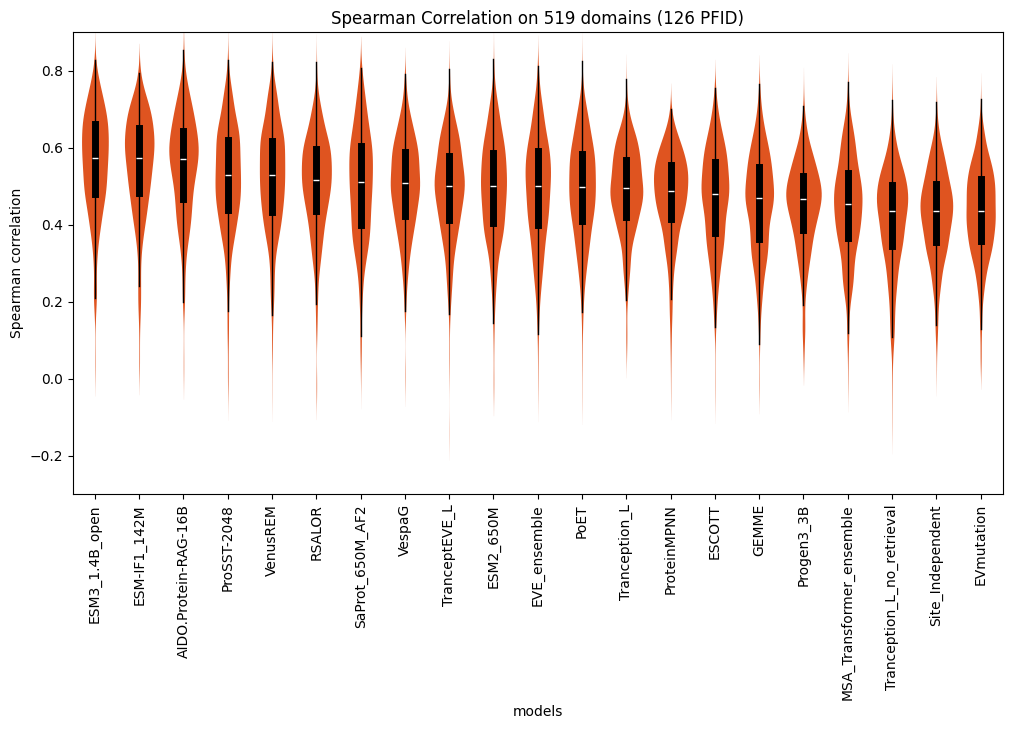

In [22]:
plt.figure(figsize=(12, 6))
DMS_spearman_df_long = DMS_spearman_df.melt(id_vars=['DMS_ID'],
                       value_vars=['Site_Independent', 'EVmutation',
                                   'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                                   'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                                   'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                                   'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B'],
                       var_name='models',
                       value_name='Spearman correlation')
sns.violinplot(data=DMS_spearman_df_long, x='models', y='Spearman correlation', 
               color='orangered', inner_kws=dict(box_width=5, whis_width=1, color="0"), 
               linewidth=0, order=sorted_spearman)

plt.ylim(-0.3, 0.9)
plt.xticks(rotation=90)
plt.title('Spearman Correlation on 519 domains (126 PFID)')
plt.savefig("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/stats/Domainome_spearman_21_models.pdf", bbox_inches="tight")

In [18]:
DMS_spearman_df[['Site_Independent', 'EVmutation',
                 'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                 'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                 'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']].median(axis=0).sort_values(ascending=False)

ESM3_1.4B_open                0.573166
ESM-IF1_142M                  0.573068
AIDO.Protein-RAG-16B          0.570856
ProSST-2048                   0.528624
VenusREM                      0.528607
RSALOR                        0.516329
SaProt_650M_AF2               0.509748
VespaG                        0.506787
TranceptEVE_L                 0.501388
ESM2_650M                     0.500135
EVE_ensemble                  0.499784
PoET                          0.498621
Tranception_L                 0.494147
ProteinMPNN                   0.488521
ESCOTT                        0.479299
GEMME                         0.469839
Progen3_3B                    0.465316
MSA_Transformer_ensemble      0.453395
Tranception_L_no_retrieval    0.436520
Site_Independent              0.435376
EVmutation                    0.434233
dtype: float64

PG1 assays

#### Conclusions:
1. All the assays, upon initial look, are classified as expression/abundance. Unlike in PG1 all assay category analyses, GEMME and other alignment-based models are no longer the top performing models, and structure based models (ESM-IF1, ProSST, and ProteinMPNN perform way better than in PG1), which might be because the assay is based on the whether the protein variant fused to dihydrofolate reductase can affect the folding of the latter. The top performing models for expression assays from PG1 aren't top performing here. This looks more like the model performance in stability assays.
3. Consistent with PG1, protein language models of single-sequence input are relatively far from SOTA, and the best performance is achieved by hybrid models (ESM3, AIDO, VenusREM, RSALOR, all are newly developed protein language models augmented by MSA retrieval) - 4 out of top 6. However, model augmented with MSA retrieval does not always help, e.g., ProSST ~ VenusREM
4. Within each model category:
   
   MSA family specific: EVE ensemble (see caveat) > GEMME > Site Independent ~ EVmutation (different ordering from PG1)

   MSA family agnostic: TranceptEVE L (with retrieval) > PoET ~ Tranception (L) with retrieval > MSA transformer (ensemble)
   
   Single sequence: VespaG ~ ESM2 (650M) > ProGen3 (3B) > Tranception L without retrieval

   Single sequence + structure: SaProt (650M, AF2)

   Structure: ESM-IF1 > ProSST (k=2048) > ProteinMPNN

   Structure + MSA: AIDO > VenusREM > RSALOR > ESCOTT

   Single sequence, Structure & Function annotations: ESM3 (1.4B open)

5. May be good to score ESM-1v for comparison with Beltran Lehner 2025 and PG1

#### Caveat: 
1. GEMME and ESCOTT have 4 missing scores because they are only 19 amino acid
2. EVE and TranceptEVE models only have scores on residues with high column coverage in the alignment
3. Did not group the same protein (referred to as corrected average in the paper), if there are measurements on multiple proteins
4. Unlike in PG1, assays with low Spearman are NOT excluded

### Spearman correlation with NDCG top 10% (PG Fig. 2B)

#### Calculate NDCG

In [23]:
# copied from PG1: https://github.com/OATML-Markslab/ProteinGym/blob/main/proteingym/performance_DMS_benchmarks.py
def minmax(x):
    return ( (x - np.min(x)) / (np.max(x) - np.min(x)) ) 

def calc_ndcg(y_true, y_score, **kwargs):
    '''
    Inputs:
        y_true: an array of the true scores where higher score is better
        y_score: an array of the predicted scores where higher score is better
    Options:
        quantile: If True, uses the top k quantile of the distribution
        top: under the quantile setting this is the top quantile to
            keep in the gains calc. This is a PERCENTAGE (i.e input 10 for top 10%)
    Notes:
        Currently we're calculating NDCG on the continuous value of the DMS
        I tried it on the binary value as well and the metrics seemed mostly
        the same.
    '''
    if 'quantile' not in kwargs:
        kwargs['quantile'] = True
    if 'top' not in kwargs:
        kwargs['top'] = 10
    if kwargs['quantile']:
        k = np.floor(y_true.shape[0]*(kwargs['top']/100)).astype(int)
    else:
        k = kwargs['top']
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
    if isinstance(y_score, pd.Series):
        y_score = y_score.values
    gains = minmax(y_true)
    ranks = np.argsort(np.argsort(-y_score)) + 1
    
    if k == 'all':
        k = len(ranks)
    #sub to top k
    ranks_k = ranks[ranks <= k]
    gains_k = gains[ranks <= k]
    #all terms with a gain of 0 go to 0
    ranks_fil = ranks_k[gains_k != 0]
    gains_fil = gains_k[gains_k != 0]
    
    #if none of the ranks made it return 0
    if len(ranks_fil) == 0:
        return (0)
    
    #discounted cumulative gains
    dcg = np.sum([g/np.log2(r+1) for r,g in zip(ranks_fil, gains_fil)])
    
    #ideal dcg - calculated based on the top k actual gains
    ideal_ranks = np.argsort(np.argsort(-gains)) + 1
    ideal_ranks_k = ideal_ranks[ideal_ranks <= k]
    ideal_gains_k = gains[ideal_ranks <= k]
    ideal_ranks_fil = ideal_ranks_k[ideal_gains_k != 0]
    ideal_gains_fil = ideal_gains_k[ideal_gains_k != 0]
    idcg = np.sum([g/np.log2(r+1) for r,g in zip(ideal_ranks_fil, ideal_gains_fil)])
    
    #normalize
    ndcg = dcg/idcg
    
    return (ndcg)

In [24]:
DMS_NDCG = {'DMS_ID': []}

for model in model_list:
    if model not in DMS_NDCG:
        DMS_NDCG[model] = np.full(shape=len(list_DMS), fill_value=np.nan)
    else:
        print(f"Duplicate model name {model}")
    
for i, DMS_id in enumerate(list_DMS):
    print(DMS_id)
    DMS_NDCG['DMS_ID'].append(DMS_id)

    DMS_file = DMS_folder + os.sep + reference_file.iloc[i]["DMS_filename"]
    print(DMS_file)
    
    try:
        DMS_score = pd.read_csv(DMS_file)
    except:
        print(f"No DMS scores for {DMS_id}")
        continue
    
    for model in model_list:
        try:
            model_score = pd.read_csv(model_score_dir + os.sep + model_dict["model_list_zero_shot_substitutions_DMS"][model]["location"] + os.sep + DMS_id + ".csv")
        except:
            print(f"Scoring file for {DMS_id} in {model} missing")
            DMS_NDCG[model][i] = -1 # this line can be taken out later
            continue
        
        if 'DMS_score' in model_score.columns:
            DMS_NDCG[model][i] = calc_ndcg(model_score['DMS_score'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"])
        elif model == "Site_Independent" or model == "EVmutation":
            DMS_NDCG[model][i] = calc_ndcg(model_score['normalized_fitness'], model_score[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"])            
        else:
            if model == "EVE_ensemble":
                model_score['evol_indices_ensemble'] = model_score.drop('mutant', axis=1).mean(axis=1)
            merged_df = pd.merge(model_score, DMS_score, on=model_dict["model_list_zero_shot_substitutions_DMS"][model]['key'], how='inner')
            DMS_NDCG[model][i] = calc_ndcg(merged_df['DMS_score'], merged_df[model_dict["model_list_zero_shot_substitutions_DMS"][model]["input_score_name"]]*model_dict["model_list_zero_shot_substitutions_DMS"][model]["directionality"])

A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2.csv
FEZF1_HUMAN_Beltran_2025_PF00096_289
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FEZF1_HUMAN_Beltran_2025_PF00096_289.csv
SPD2B_HUMAN_Beltran_2025_PF00018_155
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SPD2B_HUMAN_Beltran_2025_PF00018_155.csv
SPD2B_HUMAN_Beltran_2025_PF00018_222
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SPD2B_HUMAN_Beltran_2025_PF00018_222.csv
A2RRE5_HUMAN_Beltran_2025_PF01846_267
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/A2RRE5_HUMAN_Beltran_2025_PF01846_267.csv
ASB14_HUMAN_Beltran_2025_PF07525_532
/n/groups/

FLNB_HUMAN_Beltran_2025_PF00630_1423
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FLNB_HUMAN_Beltran_2025_PF00630_1423.csv
FLNB_HUMAN_Beltran_2025_PF00630_2109
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FLNB_HUMAN_Beltran_2025_PF00630_2109.csv
FLNB_HUMAN_Beltran_2025_PF00630_2289
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FLNB_HUMAN_Beltran_2025_PF00630_2289.csv
TRIM3_HUMAN_Beltran_2025_PF00643_111
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/TRIM3_HUMAN_Beltran_2025_PF00643_111.csv
PR40A_HUMAN_Beltran_2025_PF00397_176
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/PR40A_HUMAN_Beltran_2025_PF00397_176.csv
PR40A_HUMAN_Beltran_2025_PF01846_395
/n/groups/marks/pr

TNNC2_HUMAN_Beltran_2025_PF13499_1
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/TNNC2_HUMAN_Beltran_2025_PF13499_1.csv
S100G_BOVIN_Beltran_2025_PF01023_1
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/S100G_BOVIN_Beltran_2025_PF01023_1.csv
VILI_CHICK_Beltran_2025_PF02209_762
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/VILI_CHICK_Beltran_2025_PF02209_762.csv
VILI_CHICK_Beltran_2025_PF02209_792
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/VILI_CHICK_Beltran_2025_PF02209_792.csv
RPC1_LAMBD_Beltran_2025_PF01381_4
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/RPC1_LAMBD_Beltran_2025_PF01381_4.csv
RAF1_HUMAN_Beltran_2025_PF02196_58
/n/groups/marks/projects/marks_lab_and

BRAF_HUMAN_Beltran_2025_PF02196_153
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/BRAF_HUMAN_Beltran_2025_PF02196_153.csv
VAV_HUMAN_Beltran_2025_PF00018_592
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/VAV_HUMAN_Beltran_2025_PF00018_592.csv
VAV_HUMAN_Beltran_2025_PF00018_782
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/VAV_HUMAN_Beltran_2025_PF00018_782.csv
ANK1_HUMAN_Beltran_2025_PF00531_1405
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ANK1_HUMAN_Beltran_2025_PF00531_1405.csv
PLCG2_HUMAN_Beltran_2025_PF00018_772
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/PLCG2_HUMAN_Beltran_2025_PF00018_772.csv
YBOX3_HUMAN_Beltran_2025_PF00313_84
/n/groups/marks/projects/mark

SOX3_HUMAN_Beltran_2025_PF00505_140
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SOX3_HUMAN_Beltran_2025_PF00505_140.csv
KDM5C_HUMAN_Beltran_2025_PF00628_319
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/KDM5C_HUMAN_Beltran_2025_PF00628_319.csv
RL35_HUMAN_Beltran_2025_PF00831_9
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/RL35_HUMAN_Beltran_2025_PF00831_9.csv
CRBB2_HUMAN_Beltran_2025_PF00030_106
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/CRBB2_HUMAN_Beltran_2025_PF00030_106.csv
NR4A2_HUMAN_Beltran_2025_PF00105_260
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/NR4A2_HUMAN_Beltran_2025_PF00105_260.csv
CBX5_HUMAN_Beltran_2025_PF00385_21
/n/groups/marks/projects/mar

...

SH319_HUMAN_Beltran_2025_PF00018_664
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SH319_HUMAN_Beltran_2025_PF00018_664.csv
SAMD9_HUMAN_Beltran_2025_PF07647_4
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SAMD9_HUMAN_Beltran_2025_PF07647_4.csv
VAX1_HUMAN_Beltran_2025_PF00046_102
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/VAX1_HUMAN_Beltran_2025_PF00046_102.csv
MAGI3_HUMAN_Beltran_2025_PF00397_287
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/MAGI3_HUMAN_Beltran_2025_PF00397_287.csv
MEX3C_HUMAN_Beltran_2025_PF00013_325
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/MEX3C_HUMAN_Beltran_2025_PF00013_325.csv
GFI1B_HUMAN_Beltran_2025_PF00096_221
/n/groups/marks/projects

CUL9_HUMAN_Beltran_2025_PF11515_367
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/CUL9_HUMAN_Beltran_2025_PF11515_367.csv
CCAR1_HUMAN_Beltran_2025_PF02037_625
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/CCAR1_HUMAN_Beltran_2025_PF02037_625.csv
ZZZ3_HUMAN_Beltran_2025_PF00249_653
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ZZZ3_HUMAN_Beltran_2025_PF00249_653.csv
MYCD_HUMAN_Beltran_2025_PF02037_363
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/MYCD_HUMAN_Beltran_2025_PF02037_363.csv
ASPM_HUMAN_Beltran_2025_PF00612_1877
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ASPM_HUMAN_Beltran_2025_PF00612_1877.csv
AHI1_HUMAN_Beltran_2025_PF00018_1053
/n/groups/marks/projects

CALL4_HUMAN_Beltran_2025_PF13499_123
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/CALL4_HUMAN_Beltran_2025_PF13499_123.csv
CALL4_HUMAN_Beltran_2025_PF13499_48
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/CALL4_HUMAN_Beltran_2025_PF13499_48.csv
TOE1_HUMAN_Beltran_2025_PF00642_298
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/TOE1_HUMAN_Beltran_2025_PF00642_298.csv
FUBP3_HUMAN_Beltran_2025_PF00013_75
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/FUBP3_HUMAN_Beltran_2025_PF00013_75.csv
ITCH_HUMAN_Beltran_2025_PF00397_428
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ITCH_HUMAN_Beltran_2025_PF00397_428.csv
ITCH_HUMAN_Beltran_2025_PF00397_474
/n/groups/marks/projects/ma

DNJC5_HUMAN_Beltran_2025_PF00226_16
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/DNJC5_HUMAN_Beltran_2025_PF00226_16.csv
WNK1_HUMAN_Beltran_2025_PF12202_481
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/WNK1_HUMAN_Beltran_2025_PF12202_481.csv
SOX17_HUMAN_Beltran_2025_PF00505_69
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SOX17_HUMAN_Beltran_2025_PF00505_69.csv
TDRD3_HUMAN_Beltran_2025_PF00567_554
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/TDRD3_HUMAN_Beltran_2025_PF00567_554.csv
ZN408_HUMAN_Beltran_2025_PF00096_383
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/ZN408_HUMAN_Beltran_2025_PF00096_383.csv
KANL2_HUMAN_Beltran_2025_PF13891_28
/n/groups/marks/projects/

SALL4_HUMAN_Beltran_2025_PF00096_899
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/SALL4_HUMAN_Beltran_2025_PF00096_899.csv
TRIM1_HUMAN_Beltran_2025_PF00643_191
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/TRIM1_HUMAN_Beltran_2025_PF00643_191.csv
PO2F3_HUMAN_Beltran_2025_PF00157_186
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/PO2F3_HUMAN_Beltran_2025_PF00157_186.csv
RCOR1_HUMAN_Beltran_2025_PF00249_383
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/RCOR1_HUMAN_Beltran_2025_PF00249_383.csv
PACN3_HUMAN_Beltran_2025_PF14604_365
/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/cleaned/PACN3_HUMAN_Beltran_2025_PF14604_365.csv
ELF5_HUMAN_Beltran_2025_PF02198_47
/n/groups/marks/proj

In [25]:
DMS_NDCG_df = pd.DataFrame(DMS_NDCG)
DMS_NDCG_df

,DMS_ID,Site_Independent,EVmutation,EVE_ensemble,MSA_Transformer_ensemble,ESM2_650M,GEMME,VespaG,Tranception_L_no_retrieval,Tranception_L,...,ProteinMPNN,SaProt_650M_AF2,PoET,ESCOTT,VenusREM,ProSST-2048,RSALOR,ESM3_1.4B_open,Progen3_3B,AIDO.Protein-RAG-16B
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,0.788699,0.766538,0.774194,0.723507,0.770878,0.779628,0.757552,0.769730,0.771626,...,0.806897,0.764189,0.770326,0.777704,0.768904,0.764143,0.783543,0.771078,0.752781,0.763690
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,0.705576,0.708082,0.696636,0.706334,0.650801,0.642005,0.699997,0.652868,0.690690,...,0.709296,0.664662,0.715274,0.709658,0.674069,0.657100,0.711069,0.661865,0.678378,0.652935
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,0.880501,0.887249,0.874418,0.889287,0.882903,0.883398,0.890894,0.871806,0.880638,...,0.881426,0.880506,0.885720,0.882692,0.881793,0.863920,0.865217,0.886167,0.830963,0.886533
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,0.947809,0.949566,0.950452,0.932077,0.939228,0.918228,0.923494,0.928688,0.935891,...,0.951536,0.948475,0.953914,0.922757,0.942557,0.935947,0.937253,0.948091,0.908989,0.942361
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,0.836276,0.823212,0.832030,0.814971,0.799136,0.792354,0.824272,0.742245,0.854188,...,0.878747,0.937207,0.821246,0.794403,0.911561,0.862381,0.833739,0.941112,0.812092,0.870758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,CD2AP_HUMAN_Beltran_2025_PF14604_1,0.795040,0.844916,0.821636,0.837274,0.867749,0.844703,0.818519,0.841769,0.846364,...,0.856603,0.867694,0.837531,0.827080,0.870347,0.870846,0.805130,0.841802,0.833071,0.868376
515,CD2AP_HUMAN_Beltran_2025_PF14604_109,0.796266,0.827217,0.824832,0.803995,0.803310,0.755558,0.780181,0.779386,0.803174,...,0.799680,0.814953,0.805300,0.773936,0.788525,0.791369,0.780101,0.773315,0.791764,0.802859
516,NCOR2_HUMAN_Beltran_2025_PF00249_613,0.747862,0.752367,0.797006,0.761538,0.703560,0.724974,0.737290,0.716327,0.740227,...,0.779506,0.778754,0.778778,0.723206,0.745108,0.760021,0.763536,0.778478,0.735108,0.776220
517,USH1C_HUMAN_Beltran_2025_PF00595_207,0.857263,0.879667,0.891923,0.880664,0.875256,0.808668,0.857103,0.826649,0.863696,...,0.803258,0.890800,0.888792,0.853824,0.865041,0.852245,0.865961,0.873213,0.805637,0.878269


In [26]:
DMS_NDCG_df.to_csv("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/stats/Domainome_NDCG_21_models.csv")

In [27]:
Spearman_median = DMS_spearman_df[['Site_Independent', 'EVmutation',
                 'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                 'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                 'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']].median(axis=0)
NDCG_median = DMS_NDCG_df[['Site_Independent', 'EVmutation',
                 'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                 'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                 'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']].median(axis=0)
Spearman_NDCG_merged_median = pd.concat([Spearman_median, NDCG_median], axis=1)
Spearman_NDCG_merged_median.columns = ['Spearman', 'NDCG@10%']

In [28]:
Spearman_NDCG_merged_median = Spearman_NDCG_merged_median.rename_axis('models').reset_index()

In [29]:
Spearman_NDCG_merged_median

,models,Spearman,NDCG@10%
0,Site_Independent,0.435376,0.839955
1,EVmutation,0.434233,0.839345
2,EVE_ensemble,0.499784,0.852110
3,MSA_Transformer_ensemble,0.453395,0.838619
4,ESM2_650M,0.500135,0.842829
5,GEMME,0.469839,0.816129
6,VespaG,0.506787,0.828107
7,Tranception_L_no_retrieval,0.436520,0.812034
8,Tranception_L,0.494147,0.836692
9,TranceptEVE_L,0.501388,0.840231


In [40]:
def color_scatterplot(row):
    if row['Spearman'] > slope * row['NDCG@10%'] + intercept:
        return 'better at distribution'
    else:
        return 'better at top'

#### Plot NDCG vs Spearman

2.1023480928644243 -1.2620341202033178
                        models  Spearman  NDCG@10%     slope  intercept  \
0             Site_Independent  0.435376  0.839955  2.102348  -1.262034   
1                   EVmutation  0.434233  0.839345  2.102348  -1.262034   
2                 EVE_ensemble  0.499784  0.852110  2.102348  -1.262034   
3     MSA_Transformer_ensemble  0.453395  0.838619  2.102348  -1.262034   
4                    ESM2_650M  0.500135  0.842829  2.102348  -1.262034   
5                        GEMME  0.469839  0.816129  2.102348  -1.262034   
6                       VespaG  0.506787  0.828107  2.102348  -1.262034   
7   Tranception_L_no_retrieval  0.436520  0.812034  2.102348  -1.262034   
8                Tranception_L  0.494147  0.836692  2.102348  -1.262034   
9                TranceptEVE_L  0.501388  0.840231  2.102348  -1.262034   
10                ESM-IF1_142M  0.573068  0.854070  2.102348  -1.262034   
11                 ProteinMPNN  0.488521  0.841027  2.102348 

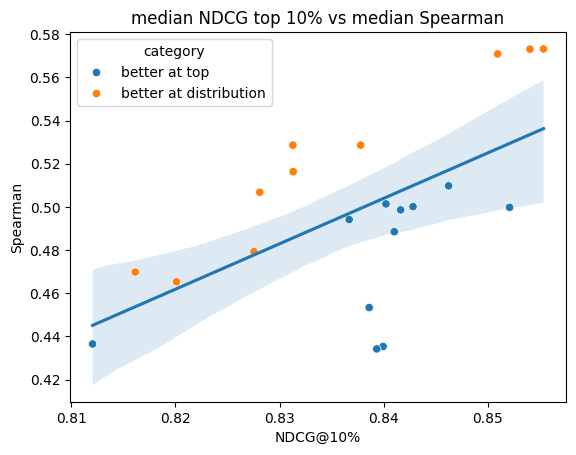

In [42]:
p = sns.regplot(y="Spearman", x="NDCG@10%", data=Spearman_NDCG_merged_median, scatter=False)
slope, intercept, r, p, sterr = linregress(x=p.get_lines()[0].get_xdata(),
                                           y=p.get_lines()[0].get_ydata())
print(slope, intercept)
Spearman_NDCG_merged_median['slope'] = slope
Spearman_NDCG_merged_median['intercept'] = intercept
print(Spearman_NDCG_merged_median)
Spearman_NDCG_merged_median['category'] = Spearman_NDCG_merged_median.apply(color_scatterplot, axis=1)
sns.scatterplot(y="Spearman", x="NDCG@10%", data=Spearman_NDCG_merged_median, hue='category')
plt.title('median NDCG top 10% vs median Spearman')
plt.savefig("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/stats/Domainome_NDCGvsSpearman_21_models.pdf", bbox_inches="tight")

#### Compare the models ranked by Spearman vs NDCG@10

In [43]:
Spearman_median_ranked = DMS_spearman_df[['Site_Independent', 'EVmutation',
                 'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                 'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                 'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']].median(axis=0).sort_values(ascending=False).index
NDCG_median_ranked = DMS_NDCG_df[['Site_Independent', 'EVmutation',
                 'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                 'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                 'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']].median(axis=0).sort_values(ascending=False).index
print(Spearman_median_ranked)
print(NDCG_median_ranked)

Index(['ESM3_1.4B_open', 'ESM-IF1_142M', 'AIDO.Protein-RAG-16B', 'ProSST-2048',
       'VenusREM', 'RSALOR', 'SaProt_650M_AF2', 'VespaG', 'TranceptEVE_L',
       'ESM2_650M', 'EVE_ensemble', 'PoET', 'Tranception_L', 'ProteinMPNN',
       'ESCOTT', 'GEMME', 'Progen3_3B', 'MSA_Transformer_ensemble',
       'Tranception_L_no_retrieval', 'Site_Independent', 'EVmutation'],
      dtype='str')
Index(['ESM3_1.4B_open', 'ESM-IF1_142M', 'EVE_ensemble',
       'AIDO.Protein-RAG-16B', 'SaProt_650M_AF2', 'ESM2_650M', 'PoET',
       'ProteinMPNN', 'TranceptEVE_L', 'Site_Independent', 'EVmutation',
       'MSA_Transformer_ensemble', 'VenusREM', 'Tranception_L', 'RSALOR',
       'ProSST-2048', 'VespaG', 'ESCOTT', 'Progen3_3B', 'GEMME',
       'Tranception_L_no_retrieval'],
      dtype='str')


#### Conclusions:
1. The model ranking by Spearman and by NDCG are quite different, though the overall correlation between the two is still present
2. Higher Spearman (from left to right): VespaG, RSALOR, ProSST, VenusREM, AIDO, ESM-IF1, ESM3; but we don't see ESM2 in this list as in PG1 and ESM models perform quite well, better than autoregressive models
3. Higher NDCG (from left to right): MSA transformer (ensemble), EVmutation, site independent (and almost EVE ensemble); consistent with PG1 that alignment-based models can fall in here

### Spearman within each PFID (mostly across different proteins)

In [44]:
output_df = pd.read_csv("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/stats/Domainome_spearman_21_models.csv")
DMS_spearman_PFID_df = output_df[['DMS_ID', 'PFID', 'number of mutants', 'Site_Independent', 'EVmutation',
       'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
       'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
       'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']]

In [45]:
DMS_spearman_PFID_df[DMS_spearman_PFID_df['PFID']=='PF00046']

,DMS_ID,PFID,number of mutants,Site_Independent,EVmutation,EVE_ensemble,MSA_Transformer_ensemble,ESM2_650M,GEMME,VespaG,...,ProteinMPNN,SaProt_650M_AF2,PoET,ESCOTT,VenusREM,ProSST-2048,RSALOR,ESM3_1.4B_open,Progen3_3B,AIDO.Protein-RAG-16B
17,PHX2A_HUMAN_Beltran_2025_PF00046_92,PF00046,1024,0.452144,0.408500,0.428249,0.480391,0.507339,0.369066,0.414956,...,0.571193,0.313220,0.448931,0.394507,0.481371,0.463481,0.592648,0.477626,0.513075,0.595139
23,SHOX_HUMAN_Beltran_2025_PF00046_119,PF00046,1021,0.483521,0.397072,0.437187,0.504834,0.494979,0.401704,0.486006,...,0.582798,0.306351,0.452529,0.397648,0.464506,0.459467,0.566663,0.497048,0.505652,0.556593
30,CRX_HUMAN_Beltran_2025_PF00046_41,PF00046,1008,0.444793,0.418541,0.447854,0.520363,0.537177,0.436232,0.481244,...,0.562849,0.412957,0.488182,0.432746,0.489058,0.492619,0.550010,0.537853,0.472168,0.610336
42,PROP1_HUMAN_Beltran_2025_PF00046_71,PF00046,1037,0.465777,0.352404,0.441461,0.450879,0.457075,0.362709,0.434796,...,0.604545,0.409192,0.434541,0.383014,0.457980,0.450613,0.571568,0.498203,0.492451,0.585738
69,ALX3_HUMAN_Beltran_2025_PF00046_155,PF00046,1014,0.410138,0.315367,0.407337,0.414401,0.444785,0.356419,0.417171,...,0.558284,0.351105,0.402373,0.383798,0.428507,0.413121,0.569286,0.457422,0.501416,0.573583
74,SIX3_HUMAN_Beltran_2025_PF00046_212,PF00046,947,0.465228,0.423429,0.595129,0.501290,0.652256,0.498183,0.602271,...,0.595340,0.423243,0.538729,0.515454,0.619542,0.622110,0.562879,0.670353,0.524512,0.700973
76,SIX6_HUMAN_Beltran_2025_PF00046_134,PF00046,946,0.460271,0.402056,0.560922,0.439159,0.620763,0.462386,0.566462,...,0.596693,0.410384,0.487539,0.479299,0.595711,0.591720,0.551149,0.643399,0.520291,0.668804
130,HXB1_HUMAN_Beltran_2025_PF00046_208,PF00046,999,0.489364,0.404009,0.464739,0.490587,0.525160,0.413465,0.513726,...,0.605534,0.351487,0.472360,0.440379,0.492291,0.483582,0.595800,0.482126,0.500780,0.659384
145,PO3F3_HUMAN_Beltran_2025_PF00046_408,PF00046,998,0.475995,0.378862,0.427248,0.392413,0.407035,0.432269,0.454572,...,0.602303,0.374981,0.471647,0.460577,0.550419,0.562425,0.601194,0.568723,0.572863,0.545483
147,PO3F2_HUMAN_Beltran_2025_PF00046_356,PF00046,1056,0.480050,0.396437,0.420999,0.381697,0.425819,0.458667,0.463313,...,0.629566,0.386127,0.433533,0.491547,0.563152,0.573119,0.621727,0.582811,0.580307,0.556766


Check out the top three abundance domains: PF00046 (homeodomain), PF00096 (ZNF domain), PF00018 (SH3 domain)

Text(0.5, 1.0, 'Spearman on PF00046')

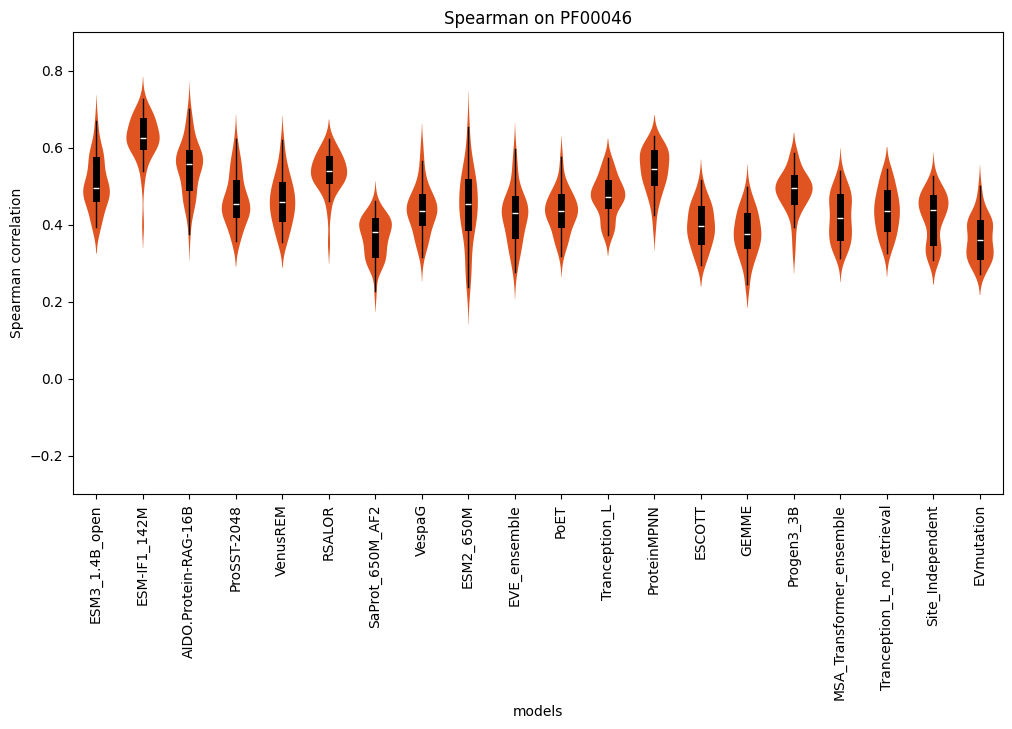

In [28]:
plt.figure(figsize=(12, 6))
PF00046_df_long = DMS_spearman_PFID_df[(DMS_spearman_PFID_df['PFID']=='PF00046') & (DMS_spearman_PFID_df['DMS_ID']!='ADNP_HUMAN_Beltran_2025_PF00046_770')].melt(id_vars=['DMS_ID'],
                       value_vars=['Site_Independent', 'EVmutation',
                                   'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                                   'Tranception_L_no_retrieval', 'Tranception_L', 'ESM-IF1_142M', 'ProteinMPNN',
                                   'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                                   'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B'],
                       var_name='models',
                       value_name='Spearman correlation')
sns.violinplot(data=PF00046_df_long, x='models', y='Spearman correlation', 
               color='orangered', inner_kws=dict(box_width=5, whis_width=1, color="0"), 
               linewidth=0, order=sorted_spearman)

plt.ylim(-0.3, 0.9)
plt.xticks(rotation=90)
plt.title('Spearman on PF00046')

Text(0.5, 1.0, 'Spearman on PF00096')

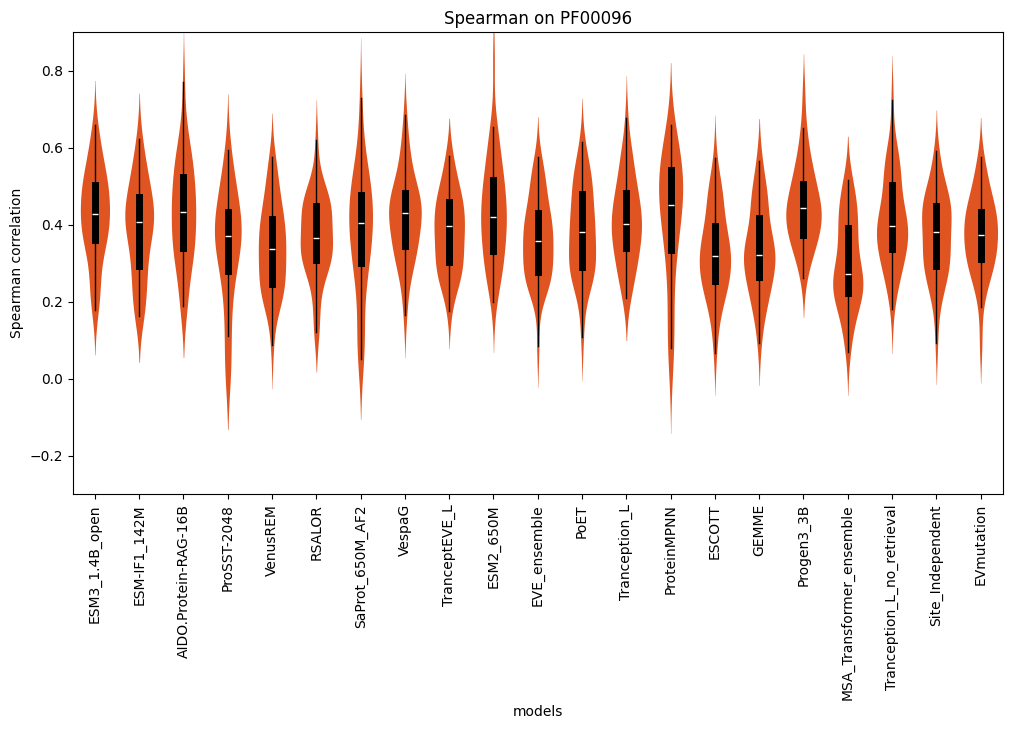

In [46]:
plt.figure(figsize=(12, 6))
PF00096_df_long = DMS_spearman_PFID_df[DMS_spearman_PFID_df['PFID']=='PF00096'].melt(id_vars=['DMS_ID'],
                       value_vars=['Site_Independent', 'EVmutation',
                                   'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                                   'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                                   'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                                   'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B'],
                       var_name='models',
                       value_name='Spearman correlation')
sns.violinplot(data=PF00096_df_long, x='models', y='Spearman correlation', 
               color='orangered', inner_kws=dict(box_width=5, whis_width=1, color="0"), 
               linewidth=0, order=sorted_spearman)

plt.ylim(-0.3, 0.9)
plt.xticks(rotation=90)
plt.title('Spearman on PF00096')

Text(0.5, 1.0, 'Spearman on PF00018')

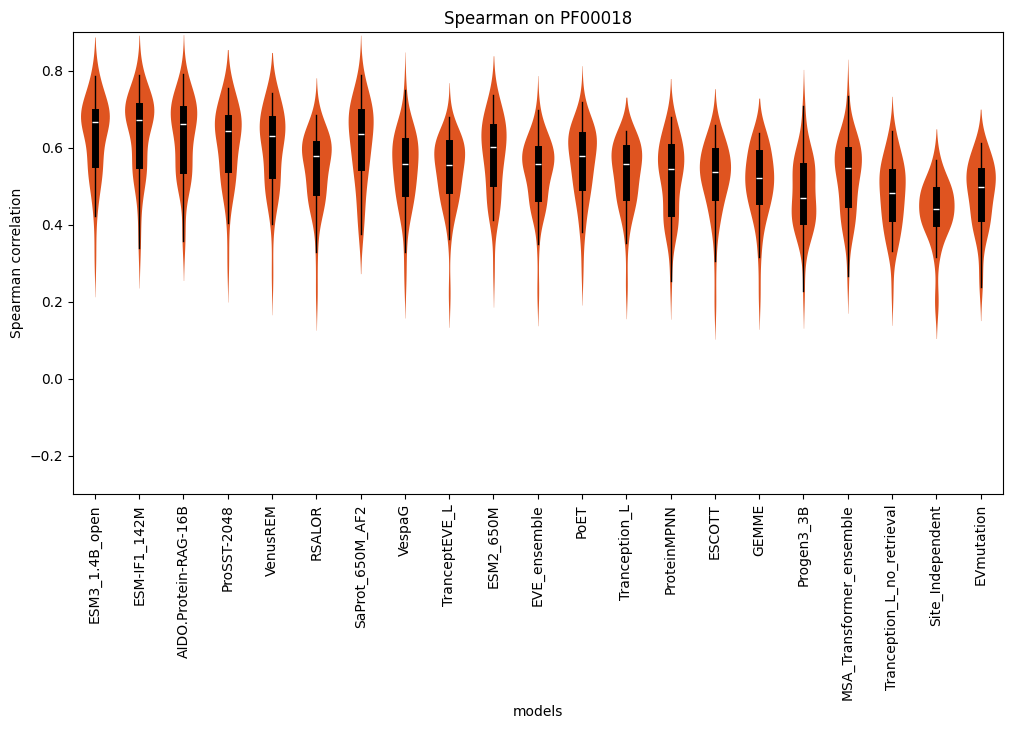

In [47]:
plt.figure(figsize=(12, 6))
PF00018_df_long = DMS_spearman_PFID_df[DMS_spearman_PFID_df['PFID']=='PF00018'].melt(id_vars=['DMS_ID'],
                       value_vars=['Site_Independent', 'EVmutation',
                                   'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
                                   'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
                                   'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 
                                   'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B'],
                       var_name='models',
                       value_name='Spearman correlation')
sns.violinplot(data=PF00018_df_long, x='models', y='Spearman correlation', 
               color='orangered', inner_kws=dict(box_width=5, whis_width=1, color="0"), 
               linewidth=0, order=sorted_spearman)

plt.ylim(-0.3, 0.9)
plt.xticks(rotation=90)
plt.title('Spearman on PF00018')

### Spearman by MSA depth (PG Appendix A6) (less interesting)

In [48]:
DMS_metadata_df['MSA_depth'].value_counts()

MSA_depth
Medium    508
Low        10
High        1
Name: count, dtype: int64

In [50]:
DMS_spearman_MSA_depth_df = output_df[['MSA_depth', 'Site_Independent', 'EVmutation',
       'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
       'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
       'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']]
mean_by_depth = DMS_spearman_MSA_depth_df.groupby('MSA_depth')[['Site_Independent', 'EVmutation',
       'EVE_ensemble', 'MSA_Transformer_ensemble', 'ESM2_650M', 'GEMME', 'VespaG',
       'Tranception_L_no_retrieval', 'Tranception_L', 'TranceptEVE_L', 'ESM-IF1_142M', 'ProteinMPNN',
       'SaProt_650M_AF2', 'PoET', 'ESCOTT', 'VenusREM', 'ProSST-2048', 'RSALOR', 'ESM3_1.4B_open', 'Progen3_3B', 'AIDO.Protein-RAG-16B']].mean()
mean_by_depth = mean_by_depth.transpose()
mean_by_depth[['Low', 'Medium', 'High']]

MSA_depth,Low,Medium,High
Site_Independent,0.326097,0.428593,0.419332
EVmutation,0.315223,0.434264,0.417721
EVE_ensemble,0.308331,0.489391,0.481263
MSA_Transformer_ensemble,0.218792,0.448580,0.461461
ESM2_650M,0.433978,0.491176,0.477451
GEMME,0.313186,0.459421,0.472320
VespaG,0.453665,0.500888,0.505171
Tranception_L_no_retrieval,0.362814,0.415814,0.371618
Tranception_L,0.390843,0.489449,0.455719
TranceptEVE_L,0.361439,0.491575,0.478916


In [51]:
mean_by_depth['Medium'].sort_values(ascending=False)

ESM3_1.4B_open                0.560331
ESM-IF1_142M                  0.555457
AIDO.Protein-RAG-16B          0.553454
VenusREM                      0.521528
ProSST-2048                   0.521503
RSALOR                        0.507540
SaProt_650M_AF2               0.501237
VespaG                        0.500888
TranceptEVE_L                 0.491575
PoET                          0.491455
ESM2_650M                     0.491176
Tranception_L                 0.489449
EVE_ensemble                  0.489391
ProteinMPNN                   0.474976
ESCOTT                        0.469190
GEMME                         0.459421
Progen3_3B                    0.449884
MSA_Transformer_ensemble      0.448580
EVmutation                    0.434264
Site_Independent              0.428593
Tranception_L_no_retrieval    0.415814
Name: Medium, dtype: float64

In [70]:
pg1_file = '/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/notebooks/DMS_substitutions.csv'
pg1_ref = pd.read_csv(pg1_file)
pg1_ref['MSA_Neff_L_category'].value_counts()

MSA_Neff_L_category
Medium    109
High       72
Low        36
Name: count, dtype: int64

Likely not super comparable with PG1, because only 10 assays have low MSA depth and 1 assay has high MSA depth.

If we only look at medium MSA depth: GEMME is no longer the top performing model, and hybrid models and structure models do best

Can do more comparison by parsing files from `/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym/model_scores/merged_scores/zero_shot_substitutions/20250613`